# 4 编码器部分实现

## 学习目标
- 了解编码器中各个组成部分的作用。
- 掌握编码器中各个组成部分的实现过程。

## 1 编码器介绍
编码器部分：* 由N个编码器层堆叠而成 * 每个编码器层由两个子层连接结构组成 * 第一个子层连接结构包括一个多头自注意力子层和规范化层以及一个残差连接 * 第二个子层连接结构包括一个前馈全连接子层和规范化层以及一个残差连接

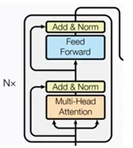

## 2 掩码张量

### 2.1 掩码张量介绍

- 掩代表遮掩，码就是我们张量中的数值，它的尺寸不定，里面一般只有1和0的元素，代表位置被遮掩或者不被遮掩，至于是0位置被遮掩还是1位置被遮掩可以自定义，因此它的作用就是让另外一个张量中的一些数值被遮掩，也可以说被替换，它的表现形式是一个张量。

### 2.2 掩码张量的作用

- 在transformer中，掩码张量的主要作用在应用attention(将在下一小节讲解)时，有一些生成的attention张量中的值计算有可能已知了未来信息而得到的，未来信息被看到是因为训练时会把整个输出结果都一次性进行Embedding，但是理论上解码器的输出却不是一次就能产生最终结果的，而是一次次通过上一次结果综合得出的，因此，未来的信息可能被提前利用。所以，我们会进行遮掩。关于解码器的有关知识将在后面的章节中讲解。

### 2.3 生成掩码张量的代码分析

In [ ]:
def subsequent_mask(size):
    """生成后向遮掩的掩码张量，参数size是掩码张量最后两个维度的大小，它的最后两维形成一个方阵"""
    # 在函数中，首先定义掩码张量的形状
    attn_shape = (1, size, size)

    # 然后使用np.ones方法向这个形状中添加1元素，形成上三角阵，最后为了节约空间，
    # 再使用中的数据类型变为无符号8位整形uint8
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')

    # 最后将numpy类型转化为torch中的tensor，内部做一个1 - 的操作，
    # 在这个其实是做了一个三角阵的反转，subsequent_mask中的每个元素都会被1减，
    # 如果是0，subsequent_mask中的该位置由0变成1
    # 如果是1，subsequent_mask中的该位置由1变成0
    return torch.from_numpy(1 - subsequent_mask)

- np.triu演示：

In [ ]:
np.triu([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], k=-1)
# array([[ 1,  2,  3],
#        [ 4,  5,  6],
#        [ 0,  8,  9],
#        [ 0,  0, 12]])
np.triu([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], k=0)
# array([[ 1,  2,  3],
#     [ 0,  5,  6],
#     [ 0,  0,  9],
#     [ 0,  0,  0]])

np.triu([[1,2,3],[4,5,6],[7,8,9],[10,11,12]], k=1)
# array([[ 0,  2,  3],
#     [ 0,  0,  6],
#     [ 0,  0,  0],
#     [ 0,  0,  0]])

> - 输入实例：

In [ ]:
# 生成的掩码张量的最后两维的大小
size = 5

> - 调用：

In [ ]:
sm = subsequent_mask(size)
print("sm:", sm)

> - 输出效果：

In [ ]:
# 最后两维形成一个下三角阵

# sm: (0, ..., 0) =
#   1 1 1 1 1 1 1 1 1 1
#   1 1 1 1 1 1 1 1 1 0
#   1 1 1 1 1 1 1 1 0 0
#   1 1 1 1 1 1 1 0 0 0
#   1 1 1 1 1 1 0 0 0 0
#   1 1 1 1 1 0 0 0 0 0
#   1 1 1 1 0 0 0 0 0 0
#   1 1 0 0 0 0 0 0 0 0
#   1 0 0 0 0 0 0 0 0 0
#   0 0 0 0 0 0 0 0 0 0

# [torch.ByteTensor of size 1x5x5]

## 2.4 掩码张量的可视化

In [1]:
plt.figure(figsize=(5,5))
plt.imshow(subsequent_mask(20)[0])

NameError: name 'plt' is not defined

> - 输出效果

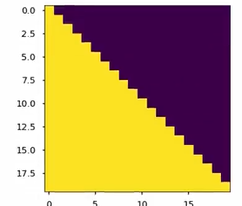

- 效果分析：
  
  - 通过观察可视化方阵，黄色是1的部分，这里代表被遮掩，紫色代表没有被遮掩的信息，横坐标代表目标词汇的位置，纵坐标代表可查看的位置；

  - 我们看到，在0的位置我们一看过去都是黄色的，都被遮住了，1的位置一眼望过去还是黄色，说明第一次词还没有产生，从第二个位置看过去，就能看到位置1的词，其他位置看不到，以此类推。

## 2.5 掩码张量总结

- 学习了什么是掩码张量：
  - 掩代表遮掩，码就是我们张量中的数值，它的尺寸不定，里面一般只有1和0的元素，代表位置被遮掩或者不被遮掩，至于是0位置被遮掩还是1位置被遮掩可以自定义，因此它的作用就是让另外一个张量中的一些数值被遮掩，也可以说被替换，它的表现形式是一个张量。

- 学习了掩码张量的作用：
  - 在transformer中，掩码张量的主要作用在应用attention(将在下一小节讲解)时，有一些生成的attention张量中的值计算有可能已知量未来信息而得到的，未来信息被看到是因为训练时会把整个输出结果都一次性进行Embedding，但是理论上解码器的输出却不是一次就能产生最终结果的，而是一次次通过上一次结果综合得出的，因此，未来的信息可能被提前利用。所以，我们会进行遮掩。关于解码器的有关知识将在后面的章节中讲解。

- 学习并实现了生成向后遮掩的掩码张量函数：subsequent_mask
  - 它的输入是size，代表掩码张量的大小。
  - 它的输出是一个最后两维形成1方阵的下三角阵。
  - 最后对生成的掩码张量进行了可视化分析，更深一步理解了它的用途。

# 3 注意力机制

我们这里使用的注意力的计算规则：

$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{Q \cdot K^T}{\sqrt{d_k}}\right) \cdot V$$

## 3.1 注意力计算规则的代码分析

In [ ]:
import torch
import torch.nn.functional as F
import math

def attention(query, key, value, mask=None, dropout=None):
    """
        注意力机制的实现，输入分别是query, key, value, mask：掩码张量，
        和dropout是nn.Dropout层的实例化对象，默认为None
    """
    
    # 在函数中，首先取query的最后一位作为掩码，一般情况下就等同于我们的词嵌入维度，命名为d_k
    d_k = query.size(-1)
    # 按照注意力公式，将query与key的转置相乘，这里面key是将最后两位维度进行转置，再除以缩放系数
    # 得到注意力得分张量scores
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    # 接着判断是否使用掩码张量
    if mask is not None:
        # 使用tensor的masked_fill方法，将掩码张量和scores张量每个位置一一比较，如果掩码张量值为0，
        # 则对应的scores张量用-1e9这个值来替换，如下所示
        scores = scores.masked_fill(mask == 0, -1e9)

    # 对scores的最后一位进行softmax操作，使用F.softmax方法，第一个参数是softmax对象，
    # 第二个参数是维度dim=-1，这样获得最终的注意力张量
    p_attn = F.softmax(scores, dim=-1)

    # 之后判断是否使用dropout进行随机置0
    if dropout is not None:
        # 将p_attn传入dropout对象中进行丢弃处理
        p_attn = dropout(p_attn)

    # 最后，根据公式将p_attn与value张量相乘获得最终的query注意力表示，同时返回注意力张量
    return torch.matmul(p_attn, value), p_attn

- tensor.masked_fill演示:

In [ ]:
input = Variable(torch.randn(5, 5))
input
# Variable containing:
#   2.0344 -0.5450  0.3365 -0.1888 -2.1803
#   1.5221 -0.3823  0.8414  0.7836 -0.8481
#  -0.0345 -0.8643  0.6476 -0.2713  1.5645
#   0.8788 -2.2142  0.4022  0.1997  0.1474
#   2.9109  0.6006 -0.6745 -1.7262  0.6977

# [torch.FloatTensor of size 5x5]

mask = Variable(torch.zeros(5, 5))
mask
# Variable containing:
#   0  0  0  0  0
#   0  0  0  0  0
#   0  0  0  0  0
#   0  0  0  0  0
#   0  0  0  0  0

# [torch.FloatTensor of size 5x5]

input.masked_fill(mask == 0, -1e9)
# Variable containing:
#  -1.0000e+09 -1.0000e+09 -1.0000e+09 -1.1000e+09 -1.0000e+09
#  -1.0000e+09 -1.0000e+09 -1.0000e+09 -1.1000e+09 -1.0000e+09
#  -1.0000e+09 -1.0000e+09 -1.0000e+09 -1.1000e+09 -1.0000e+09
#  -1.0000e+09 -1.0000e+09 -1.0000e+09 -1.1000e+09 -1.0000e+09
#  -1.0000e+09 -1.0000e+09 -1.0000e+09 -1.1000e+09 -1.0000e+09

# [torch.FloatTensor of size 5x5]

- 输入参数：

In [ ]:
# 我们令输入的query、key、value都相同，位置编码的输出
query = key = value = pe_result

# Variable containing:
# ( 0 , ... ) ↑
#   46.5196   16.2057  -41.5581  ...    -16.0242  -17.8929  -43.0405
#   -32.6040   16.1096  -29.5228  ...    4.2721    20.6034  -1.2747
#   -18.6235   14.5076  -2.0105  ...    15.6462  -24.6081  -30.3391
#     0.0000  -66.1486  -11.5123  ...    20.1519  -4.6823    0.4916

# ( 1 , ... ) =
#   -24.8681    7.5495  -5.0765  ...    -7.5992  -26.6630  40.9517
#    13.1581  -3.1918  -30.9001  ...    25.1187  -26.4621   2.9542
#   -49.7690  -42.5019   8.0198  ...    -5.4809   25.9403  -27.4931
#   -52.2775   10.4006   0.0000  ...    -1.9985   7.0106  -0.5189

# [torch.FloatTensor of size 2x4x512]

- 调用

In [ ]:
attn, p_attn = attention(query, key, value)
print("attn:", attn)
print("p_attn:", p_attn)

- 输出效果

In [ ]:
# 将得到两个结果
# query的注意力表示：

# attn: Variable containing:
# ( 0 , ... ) =
#   12.8269   7.7403   41.2225    ...    1.4603   27.8559   -12.2600
#   12.4904   0.0000   24.1575    ...    0.0000   2.5838   18.0647
#  -32.5959  -4.6252  -29.1050    ...    0.0000  -22.6409  -11.8341
#    8.9921  -33.0114  -0.7393    ...    4.7871  -5.7735   8.3374

# ( 1 , ... ) =
#  -25.6705  -4.0860  -36.8226    ...    37.2346  -27.3576   2.5497
#  -16.6674  73.9788  -33.3296    ...    28.5028  -5.5488  -13.7564
#    0.0000  -29.9039  -3.0405    ...    0.0000   14.4408   14.8579
#   30.7819   0.0000   21.3908    ...    -29.0746   0.0000    -5.8475

# [torch.FloatTensor of size 2x4x512]

# 注意力张量：

# p_attn: Variable containing:
# ( 0 , ... ) =
#   1   0   0   0
#   0   1   0   0
#   0   0   1   0
#   0   0   0   1

# ( 1 , ... ) =
#   1   0   0   0
#   0   1   0   0
#   0   0   1   0
#   0   0   0   1

# [torch.FloatTensor of size 2x4x4]

## 3.2 带有mask的输入参数：

In [ ]:
query = key = value = pe_result

# 令mask为一个2x4x4的零张量
mask = Variable(torch.zeros(2, 4, 4))

- 调用：

In [ ]:
attn, p_attn = attention(query, key, value, mask=mask)
print("attn:", attn)
print("p_attn:", p_attn)

- 带有mask的输出效果：

In [2]:
# query的注意力表示：

# attn: Variable containing:
# (0, ..., ...) =
#   0.4284  -7.4741   8.8839  ...    1.5618   0.5063   0.5770
#   0.4284  -7.4741   8.8839  ...    1.5618   0.5063   0.5770
#   0.4284  -7.4741   8.8839  ...    1.5618   0.5063   0.5770
#   0.4284  -7.4741   8.8839  ...    1.5618   0.5063   0.5770

# (1, ..., ...) =
#   -2.8890   9.9972  -12.9505  ...    9.1657  -4.6164  -0.5491
#   -2.8890   9.9972  -12.9505  ...    9.1657  -4.6164  -0.5491
#   -2.8890   9.9972  -12.9505  ...    9.1657  -4.6164  -0.5491
#   -2.8890   9.9972  -12.9505  ...    9.1657  -4.6164  -0.5491

# [torch.FloatTensor of size 2x4x512]

# 注意力张量：
# p_attn: Variable containing:
# (0, ...,) =
#   0.2500  0.2500  0.2500  0.2500
#   0.2500  0.2500  0.2500  0.250
#   0.2500  0.2500  0.2500  0.25
#   0.2500  0.2500  0.2500  0.2500

# (1, ...,) =
#   0.2500  0.2500  0.2500  0.250
#   0.2500  0.2500  0.2500  0.2500
#   0.2500  0.2500  0.2500  0.25
#   0.2500  0.2500  0.2500  0.2500

# [torch.FloatTensor of size 2x4x4]

### 3.3 注意力机制总结

- 学习并实现了注意力计算规则的函数：attention
  - 它的输入就是Q、K、V以及mask和dropout，mask用于掩码，dropout用于随机置0。
  - 它的输出有两个，query的注意力表示以及注意力张量。

# 4 多头注意力机制

## 4.1 多头注意力机制概念

- 从多头注意力的结构图中，貌似这个所谓的多个头就是指多组线性变换层，其实并不是，我只有使用了一组线性变化层，即三个变换张量对 \( Q \)、\( K \)、\( V \) 分别进行线性变换，这些变换不会改变原有张量的尺寸，因此每个变换矩阵都是方阵，得到输出结果后，多头的作用才开始显现，每个头开始从词义层面分割输出的张量，也就是每个头都想获得一组 \( Q \)、\( K \)、\( V \) 进行注意力机制的计算，但是句子中的每个词的表示只获得一部分，也就是只分割了最后一维的嵌入向量。这就是所谓的多头，将每个头的获得的输入送到注意力机制中，就形成多头注意力机制。

## 4.2 多头注意力机制结构图

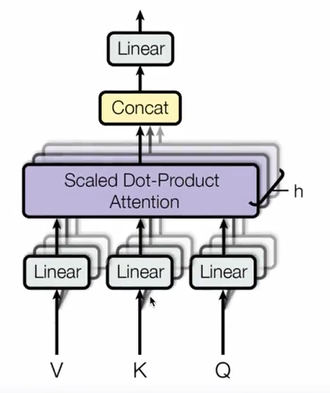

### 4.3 多头注意力机制的作用

- 这种结构设计能让每个注意力机制去优化每个词汇的不同特征部分，从而均衡同一种注意力机制可能产生的偏差，让词义拥有更多元的表达，实验表明可以从而提升模型效果。

### 4.4 多头注意力机制的代码实现

In [ ]:
# 用于深度拷贝的copy工具包
import copy
import torch.nn as nn

# 首先需要定义克隆函数，因为在多头注意力机制的实现中，用到多个结构相同的线性层。
# 我们将使用clone函数将他们一同初始化在一个网络层列表对象中，之后的结构中也会用到该函数。
def clones(module, N):
    """用于生成相同网络层的克隆函数，它的参数module表示要克隆的目标网络层，N代表需要克隆的数量"""
    # 在函数中，我们通过for循环对module进行N次深度拷贝，使其每个module成为独立的层。
    # 然后将其放在nn.ModuleList类型的列表中存放。
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

# 我们使用一个类来实现多头注意力机制的处理
class MultiHeadedAttention(nn.Module):
    def __init__(self, head, embedding_dim, dropout=0.1):
        """在类的初始化中，会传入三个参数，head代表头数，embedding_dim代表词嵌入的维度，dropout代表进行dropout操作时置0比率，默认是0.1"""
        super(MultiHeadedAttention, self).__init__()

        # 在函数中，首先使用了一个测试中常用的assert语句，判断embedding_dim是否能被head整除。
        # 这是因为我们之后要给每个头分配等量的词特征，也就是embedding_dim/head个。
        assert embedding_dim % head == 0

        # 得到每个头获得的分割词向量维度d_k
        self.d_k = embedding_dim // head

        # 传入头数h
        self.head = head

        # 然后获得线性层对象，通过nn的Linear实例化，它的内部变换矩阵是 embedding_dim x embedding_dim。
        # 为什么是四个呢？这是因为多头注意力中，Q、K、V各需要一个线性变换，最后将多头拼接后的结果还需要一个输出线性变换，
        # 因此一共需要4个线性层。
        self.linears = clones(nn.Linear(embedding_dim, embedding_dim), 4)
        
        # self.attn为None，它代表最后得到的注意力张量，现在还没有结果所以为None。
        self.attn = None

        # 最后就是一个self.dropout对象，它通过nn中的Dropout实例化而来，置0比率为传递的参数
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        """前向逻辑函数，它的输入参数有四个，前三个就是注意力机制需要的Q、K、V，
        最后一个就是注意力机制中可能需要的mask掩码张量，默认是None。"""

        # 如果存在掩码张量mask
        if mask is not None:
            # 使用unsqueeze拓展维度
            mask = mask.unsqueeze(0)

        # 接着，我们获得一个batch_size的变量，它是query尺寸的第1个数字，代表有多少条样本。
        batch_size = query.size(0)

        # 之后就进入多头处理环节
        # 首先利用zip将输入QKV与三个线性层组合到一起，然后使用for循环，将输入QKV分别传到线性层中。
        # 做完线性变换后，开始为每个头分别输入，这里使用view方法对线性变换的结果进行维度重塑，
        # 这样意味着每个头可以获得一部分特征组成的句子，其中的-1代表自适应维度。
        # 计算机会根据这种变换自动计算这里的值，然后对第二维和第三维进行维度操作。
        # 为了让代表句子长度维度和词向量维度能够相等，这样注意力机制才能找到词与句子位置的关系。
        # 从attention函数中可以看到，利用的是原始输入的倒数第一和第二维，这样我们就得到了每个头的输入。
        query, key, value = \
            [lin(x).view(batch_size, -1, self.head, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))]

        # 得到每个头的输入后，接下来就是将他们传入到attention中。
        # 这里直接调用我们之前实现的attention函数，同时将mask和dropout传入其中。
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        
        # 通过多头注意力计算后，我们就得到了每个头计算结果组成的4维张量，我们需要将其转换为输入的维度形状。
        # 因此这里开始进行第一步处理环节的逆操作，先对第二和第三维进行转置，然后使用contiguous()方法，
        # 这个方法的作用就是能够让转置后的张量应用view方法，否则将无法直接使用view，
        # 所以，下一步就是使用view重塑形状，变成和输入形状相同。
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.head * self.d_k)

        # 最后使用线性层列表中的最后一个线性层对输入进行线性变换得到最终的多头注意力结构的输出。
        return self.linears[-1](x)

- tensor.view 演示:

In [ ]:
x = torch.randn(4, 4)
x.size()
# torch.Size([4, 4])
y = x.view(16)
y.size()
# torch.Size([16])
z = x.view(-1, 8)  # the size -1 is inferred from other dimensions
z.size()
# torch.Size([2, 8])

a = torch.randn(1, 2, 3, 4)
a.size()
# torch.Size([1, 2, 3, 4])
b = a.transpose(1, 2)  # Swaps 2nd and 3rd dimension
b.size()
# torch.Size([1, 3, 2, 4])
c = a.view(1, 3, 2, 4)  # Does not change tensor layout in memory
c.size()
# torch.Size([1, 3, 2, 4])
torch.equal(b, c)
# False

- torch.transpose 演示:

In [ ]:
x = torch.randn(2, 3)
x
# tensor([[ 1.0028, -0.9893,  0.5809],
#         [-0.1669,  0.7299,  0.4942]])
torch.transpose(x, 0, 1)
# tensor([[ 1.0028, -0.1669],
#         [-0.9893,  0.7299],
#         [ 0.5809,  0.4942]])

- 实例化参数:

In [5]:
# 头数 head
head = 8

# 词嵌入维度 embedding_dim
embedding_dim = 512

# 置零比率 dropout
dropout = 0.2

- 输入参数：

In [ ]:
# 假设输入的Q、K、V仍然相等
query = value = key = pe_result

# 输入的掩码张量mask
mask = Variable(torch.zeros(8, 4, 4))

- 调用：

In [ ]:
mha = MultiHeadedAttention(head, embedding_dim, dropout)
mha_result = mha(query, key, value, mask)
print(mha_result)

- 输出效果：

In [ ]:
# tensor([[ 0.3075,  1.5687, -2.5693, ..., -1.1098,  0.0878, -3.3609],
#     [ 3.8065, -2.4538, -0.3708, ..., -1.5205, -1.1488, -1.3984],
#     [ 2.4190,  0.5376, -2.8475, ...,  1.4218, -0.4488, -0.2984],
#     [ 2.9356,  0.3620, -3.8722, ..., -0.7996,  0.1468,  1.0345]])

#     [[ 1.1423,  0.6038,  0.0954, ...,  2.2679, -5.7749,  1.4132],
#     [ 2.4066, -0.2777,  2.8102, ...,  0.1137, -3.9517, -2.9246],
#     [ 5.8201,  1.1534, -1.9191, ...,  0.1410, -7.6110,  1.0046],
#     [ 3.1209,  1.0008, -0.5317, ...,  2.8619, -6.3204, -1.3435]])

#     grad_fn=<AddBackward0>)
# torch.Size([2, 4, 512])

# 4.5 多头注意力机制总结

- 学习了什么是多头注意力机制：
  - 每个头开始从词义层面分割输出的张量，也就是每个头都想获得一组Q、K、V进行注意力机制的计算，但是句子中的每个词的表示只获得一部分，也就是只分割了最后一维的词嵌入向量。这就是所谓的多头。将每个头的获得的输入送到注意力机制中，就形成了多头注意力机制。

- 学习了多头注意力机制的作用：
  - 这种结构设计能让每个注意力机制去优化每个词汇的不同特征部分，从而均衡同一种注意力机制可能产生的偏差，让词义拥有更多元的表达，实验表明可以从而提升模型效果。

- 学习并实现了多头注意力机制的类：MultiHeadedAttention
  - 因为多头注意力机制中需要使用多个相同的线性层，首先实现了克隆函数clones。
  - clones函数的输入是module、N、分别代表克隆的目标层、和克隆个数。
  - clones函数的输出是装有N个克隆层的Module列表。
  - 接着实现MultiHeadedAttention类，它的初始化函数输入是h、d_model、dropout分别代表头数、词嵌入维度和置零比率。
  - 它的实例化对象输入是Q、K、V以及掩码张量mask。
  - 它的实例化对象输出是通过多头注意力机制处理的Q的注意力表示。

# 5 前馈全连接层

## 5.1 前馈全连接层

- 在Transformer中前馈全连接层就是具有两层线性层的全连接网络。
- 前馈全连接层的作用：
  - 考虑注意力机制可能对复杂过程的拟合程度不够，通过增加两层网络来增强模型的能力。

# 5.2 前馈全连接层的代码分析

In [ ]:
# 通过类PositionwiseFeedForward来实现前馈全连接层
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        """
            初始化函数有三个输入参数分别是d_model、d_ff和dropout=0.1，第一个是线性层的输入维
            数，第二个是dropout，第三个是dropout的维度不变。第二个参数d_ff就是第二个线性层
            最后一个参数dropout是比率。
        """
        super(PositionwiseFeedForward, self).__init__()

        # 首先按照我们预期使用nn实例化了两个线性层对象，self.w1和self.w2
        # 它们的参数分别是d_model、d_ff和d_ff、d_model
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        # 然后使用nn的Dropout实例化了两个对象self.dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """输入参数为x，代表来自上一层的输出"""
        # 首先经过第一个线性层，然后使用Funtional中relu函数进行激活。
        # 之后再使用dropout进行随机置0，最后通过第二个线性层w2，返回最终结果。
        return self.w2(self.dropout(F.relu(self.w1(x))))

* ReLU函数公式：$$\text{ReLU}(x) = \max(0, x)$$

* ReLU函数图像：

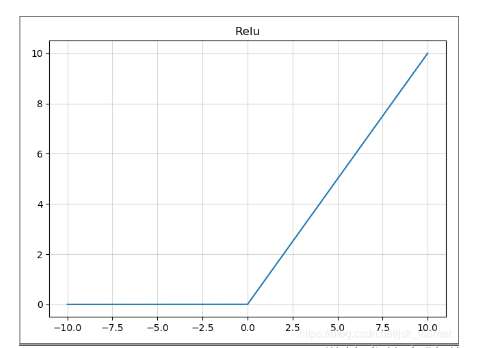

# 6 规范化层

## 6.1 规范化层的作用

* 它是所有深层网络模型都需要标准网络层，因为随着网络层数的增加，通过多层的计算后参数可能开始出现过大或过小的情况，这样可能会导致学习过程出现异常，模型可能收敛非常的慢. 因此都会在一定层数后接规范化层进行数值的规范化，使其特征数值在合理范围内.

## 6.2 规范化层的代码实现

In [ ]:
import torch
import torch.nn as nn

# 通过LayerNorm实现规范化层的类
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        """初始化函数有两个参数，一个是features，表示训练的维度，
        另一个是eps它是一个足够小的数，在规范化公式的分母中出现，
        防止分母为0。默认是1e-6."""
        super(LayerNorm, self).__init__()

        # 根据features的形状初始化两个参数张量a2 和 b2，第一个初始化为1张量。
        # 也就是里面的元素都是1，第二个初始化为0张量，也就是里面的元素都是0，这两个张量就是规范化层的初始值。
        # 因为直接对上一层得到的结果做规范化公式计算，将改变结果的正常表现，因此就需要有参数作为初始值。
        # 使其能够满足规范化要求，又不能改变对目标的表征。最后使用nn.Parameter封装，代表他们具有参数。
        self.a2 = nn.Parameter(torch.ones(features))
        self.b2 = nn.Parameter(torch.zeros(features))

        # 把eps传到类中
        self.eps = eps

    def forward(self, x):
        """输入参数x代表来自上一层的输出"""
        # 在函数中，首先对输入变量x求其最后一个维度的均值，并保持输出维度与输入维度一致。
        # 接着再求最后一个维度的标准差，然后就是根据规范化公式，用x减去均值除以标准差获得规范化后的值。
        # 最后对结果乘以a2的缩放参数，即a2，*号代表同层元素，即对应位置进行乘法操作，加上位移参数b2。
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a2 * (x - mean) / (std + self.eps) + self.b2

- 实例化参数：

In [7]:
features = d_model = 512
eps = 1e-6

- 输入参数：

In [ ]:
# 输入x来自前馈全连接层的输出
x = ff_result
# tensor([[1.9488e+00, -3.4060e-01, -1.1216e+00, ..., 1.8203e-01, -2.6336e+00, 2.0917e-03],
# [2.5875e-02, 1.1523e-01, -9.5437e-01, ..., -2.6257e-01, -5.7620e-01, -1.9225e-01],
# [-8.7508e-01, 1.0092e+00, -1.6515e+00, ..., 3.4446e-02, -1.5933e+00, -3.1760e-01],
# [-2.7507e-01, 4.7225e-01, -2.0318e-01, ..., 1.0530e+00, -3.7910e-01, -9.7730e-01]],

# [[-2.2575e+00, -2.0904e+00, 2.9427e+00, ..., 9.6574e-01, -1.9754e+00, 1.2797e+00],
# [-1.5114e+00, -4.7963e-01, 1.2881e+00, ..., -2.4882e-02, -1.5896e+00, -1.0350e+00],
# [1.7416e-01, -4.0688e-01, 1.9289e+00, ..., -4.9754e-01, -1.6320e+00, -1.5217e+00],
# [-1.0874e-01, -3.3842e-01, 2.9379e-01, ..., -5.1276e-01, -1.6150e+00, -1.1295e+00]], grad_fn=<AddBackward0>)
# torch.Size([2, 4, 512])

- 调用:

In [ ]:
ln = LayerNorm(features, eps)
ln_result = ln(x)
print(ln_result)

- 输出效果:

In [8]:
# tensor([[ 2.2697,  1.3911, -0.4417, ...,  0.9937,  0.6589, -1.1902],
#     [ 1.5876,  0.5182,  0.6220, ...,  0.9836,  0.0338, -1.3393],
#     [ 1.8261,  2.0161,  0.2272, ...,  0.3004,  0.5660, -0.9844],
#     [ 1.5429,  1.3221, -0.2933, ...,  0.0406,  1.0603,  1.4666]])

#     [[ 0.2378,  0.9952,  1.2621, ..., -0.4334, -1.1644,  1.2082],
#     [-1.0209,  0.6435,  0.4235, ..., -0.3448, -1.0560,  1.2347],
#     [-0.8158,  0.7118,  0.4110, ...,  0.0990, -1.4833,  1.9434],
#     [ 0.9857,  2.3924,  0.3819, ...,  0.0157, -1.6300,  1.2251]])

#     grad_fn=<AddBackward0>)
# torch.Size([2, 4, 512])

### 6.3 规范化层总结：

- 学习了规范化层的作用：
  - 它是所有深层网络模型都需要的标准网络层，因为随着网络层数的增加，通过多层的计算后参数可能开始出现过大或过小的情况，这样可能会导致学习过程出现异常，模型可能收敛非常慢。因此都会在一定层数后接规范化层进行数值的规范化，使其特征数值在合理范围内。

- 学习并实现了规范化层的类：LayerNorm
  - 它的实例化参数有两个，features和eps，分别表示词嵌入特征大小，和一个足够小的数。
  - 它的输入参数代表来自上一层的输出。
  - 它的输出就是经过规范化的特征表示。

# 7 子层连接结构

## 7.1 子层连接结构：

- 如图所示，输入到每个子层以及规范化层的过程中，还使用了残差链接（跳跃连接），因此我们把这一部分结构整体叫做子层连接（代表子层及其链接结构），在每个编码器层中，都有两个子层，这两个子层加上周围的链接结构就形成了两个子层连接结构。

- 子层连接结构图：

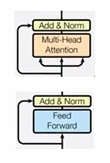

## 7.2 子层连接结构的代码分析

In [9]:
import torch.nn as nn
# 此处假设 LayerNorm 类已在之前定义（如前面的代码片段中已实现）

# 使用SublayerConnection来实现子层连接结构的类
class SublayerConnection(nn.Module):
    def __init__(self, size, dropout=0.1):
        """它输入参数有两个，size以及dropout，size一般是词嵌入维度的大小，dropout本身是对模型结构中的节点数进行随机抑制的比率，又因为节点数抑制等效就是该节点的输出都是0，因此也可以把dropout看作是对输出矩阵的随机抑制"""
        super(SublayerConnection, self).__init__()
        # 实例化了规范化对象self.norm
        self.norm = LayerNorm(size)
        # 又使用nn中预定义的dropout实例化一个self.dropout对象。
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, sublayer):
        """前向逻辑函数中，接收上一个层或者子层的输入作为第一个参数，将该子层连接中的子层函数作为第二个参数"""
        # 我们首先对输出进行规范化，然后将结果传给子层处理，之后再对子层进行dropout操作，
        # 随机化一些网络中神经元的作用，来防止过拟合。最后还有一个add操作，
        # 因为存在跳跃连接，所以是将输入x与dropout后的子层输出结果相加作为最终的子层连接输出。
        return x + self.dropout(sublayer(self.norm(x)))

- 实例化参数

In [ ]:
size = 512
dropout = 0.2
head = 8
d_model = 512

- 输入参数：

In [ ]:
# 令x为位置编码器的输出
x = pe_result
mask = Variable(torch.zeros(8, 4, 4))

# 假设子层中装的是多头注意力层，实例化这个类
self_attn = MultiHeadedAttention(head, d_model)

# 使用lambda获得一个函数类型的子层
sublayer = lambda x: self_attn(x, x, x, mask)

- 调用：

In [ ]:
sc = SublayerConnection(size, dropout)
sc_result = sc(x, sublayer)
print(sc_result)
print(sc_result.shape)

- 输出效果：

In [ ]:
# tensor([[ 14.8830,  22.4106, -31.4739,    ...    21.0882, -10.0338,  -0.2588],
#         [-25.1435,   2.9246, -16.1235,    ...    10.5069,  -7.1007,  -3.7396],
#         [   0.1374,  32.6438,  12.3680,    ...    -12.0251, -40.5829,   2.2297],
#         [-13.3123,  55.4689,   9.5420,    ...    -12.6622,  23.4496,  21.1531]],

#        [[  13.3533,  17.5674, -13.3354,    ...    29.1366,  -6.4898,  35.8614],
#         [-35.2286,  18.7378, -31.4337,    ...    11.1726,  20.6372,  29.8689],
#         [-30.7627,   0.0000, -57.0587,    ...    15.0724, -10.7196, -18.6290],
#         [-2.7757, -19.6408,   0.0000,    ...    12.7660,  21.6843, -35.4784]]],
#        grad_fn=<AddBackward0>)
# torch.Size([2, 4, 512])

# 7.3 子层连接结构总结

- 什么是子层连接结构：
  - 如图所示，输入到每个子层以及规范化层的过程中，还使用了残差链接（跳跃连接），因此我们把这一部分结构整体叫做子层连接（代表子层及其链接结构），在每个编码器层中，都有两个子层，这两个子层加上周围的链接结构就形成了两个子层连接结构。

- 学习并实现了子层连接结构的类：SublayerConnection
  - 类的初始化函数输入参数是size, dropout, 分别代表词嵌入大小和置零比率。
  - 它的实例化对象输入参数是x, sublayer, 分别代表上一层输出以及子层的函数表示。
  - 它的输出就是通过子层连接结构处理的输出。

# 8 编码器层

## 8.1 编码器层的作用

- 作为编码器的组成单元，每个编码器层完成一次对输入的特征提取过程，即编码过程。
- 编码器层的构成图：

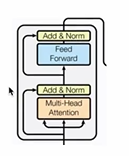

## 8.2 编码器层的代码分析

In [10]:
import torch.nn as nn
import copy

# 假设 clones 函数已在之前定义（用于深度拷贝网络层）
def clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

# 使用 EncoderLayer 类实现编码器层
class EncoderLayer(nn.Module):
    def __init__(self, size, self_attn, feed_forward, dropout):
        """它的初始化函数参数有四个，分别是 size（词嵌入维度大小），self_attn（多头自注意力子层实例），
        feed_forward（前馈全连接层实例），以及 dropout（置零比率）。"""
        super(EncoderLayer, self).__init__()

        # 首先将 self_attn 和 feed_forward 传入其中。
        self.self_attn = self_attn
        self.feed_forward = feed_forward

        # 如图所示，编码器层中有两个子层连接结构，所以使用 clones 函数进行克隆
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        # 把 size 传入其中
        self.size = size

    def forward(self, x, mask):
        """forward 函数中有两个输入参数，x 和 mask，分别代表上一层的输出，和掩码张量 mask。"""
        # 里面就是按照结构图左侧的流程。首先通过第一个子层连接结构，其中包含多头自注意力子层。
        # 然后通过第二个子层连接结构，其中包含前馈全连接子层。最后返回结果。
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

- 实例化参数：

In [ ]:
size = 512
head = 8
d_model = 512
d_ff = 64
x = pe_result
dropout = 0.2
self_attn = MultiHeadedAttention(head, d_model)
ff = PositionwiseFeedForward(d_model, d_ff, dropout)
mask = Variable(torch.zeros(8, 4, 4))

- 调用：

In [ ]:
el = EncoderLayer(size, self_attn, ff, dropout)
el_result = el(x, mask)
print(el_result)
print(el_result.shape)

- 输出效果：

In [ ]:
# tensor([[ 33.6988, -30.7224,  20.9575,    ...,    5.2968, -48.5658,  20.0734],
#     [-18.1999,  34.2358,  40.3094,   ...,    10.1102,  58.3381,  58.4962],
#     [ 32.1243,  16.7921, -6.8024,   ...,    23.0022, -18.1463, -17.1263],
#     [-9.3475, -3.3605, -55.3494,   ...,    43.6333, -0.1900,  0.1625]])

#     [[ 32.8937, -46.2808,   8.5047,   ...,    29.1837,  22.5962, -14.4349],
#     [ 21.3379,  20.0657, -31.7256,   ...,   -13.4079, -44.0706, -9.9504],
#     [ 19.7478, -1.0848,  11.8884,   ...,   -9.5794,   0.0675, -4.7123],
#     [-6.8023, -16.1176,  20.9476,   ...,   -6.5469,  34.8391, -14.9798]]]

# grad_fn=<AddBackward0>
# torch.Size([2, 4, 512])

### 8.3 编码器层总结：

- 学习了编码器层的作用：
  - 作为编码器的组成单元，每个编码器层完成一次对输入的特征提取过程，即编码过程。

- 学习并实现了编码器层的类：EncoderLayer
  - 类的初始化函数共有4个，分别是size，其实就是我们词嵌入维度的大小。第二个self_attn，之后我们将传入多头自注意力子层实例化对象，并且是自注意力机制。第三个是feed_forward，之后我们将传入前馈全连接层实例化对象。最后一个层是0比率dropout。

- 实例化对象的输入参数有2个，x代表来自上一层的输出，mask代表掩码张量。

- 它的输出代表经过整个编码层的特征表示。

### 8.3 编码器层总结：

- 学习了编码器层的作用：
  - 作为编码器的组成单元，每个编码器层完成一次对输入的特征提取过程，即编码过程。

- 学习并实现了编码器层的类：EncoderLayer
  - 类的初始化函数共有4个，分别是size，其实就是我们词嵌入维度的大小。第二个self_attn，之后我们将传入多头自注意力子层实例化对象，并且是自注意力机制。第三个是feed_forward，之后我们将传入前馈全连接层实例化对象。最后一个层是0比率dropout。

- 实例化对象的输入参数有2个，x代表来自上一层的输出，mask代表掩码张量。

- 它的输出代表经过整个编码层的特征表示。

# 9 编码器

## 9.1 编码器的作用

- 编码器用于对输入进行指定的特征提取过程，也称为编码，由N个编码器层堆叠而成。
- 编码器的结构图：

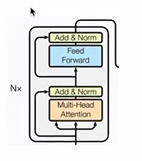

# 9.2 编码器的代码分析

In [ ]:
# 使用Encoder类来实现编码器
class Encoder(nn.Module):
    def __init__(self, layer, N):
        """初始化函数的两个参数分别代表编码器和编码器的个数"""
        super(Encoder, self).__init__()
        # 首先使用clones函数克隆N个编码器层放在self.layers中
        self.layers = clones(layer, N)
        # 再初始化一个规范化层，它将用在编码器的最后面。
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        """forward函数的输入和编码器层相同，x代表上一层的输出，mask代表掩码张量"""
        # 首先就是对编码器的编码器层进行循环，每次都会得到一个新的x。
        # 这个循环的过程，就相当于输出的x经过了N个编码器的处理。
        # 最后再通过规范化层的对象self.norm进行处理，最后返回结果。
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

- 实例化参数：

In [ ]:
# 第一个实例化参数layer，它是一个编码器层的实例化对象，因此需要传入编码器层的参数
# 又因为编码器层中的子层是不共享的，因此需要使用深度拷贝各个对象。
size = 512
head = 8
d_model = 512
d_ff = 64
c = copy.deepcopy
attn = MultiHeadedAttention(head, d_model)
ff = PositionwiseFeedForward(d_model, d_ff, dropout)
dropout = 0.2
layer = EncoderLayer(size, c(attn), c(ff), dropout)

# 编码器中编码器层的个数N
N = 8
mask = Variable(torch.zeros(8, 4, 4))

- 调用：

In [ ]:
en = Encoder(layer, N)
en_result = en(x, mask)
print(en_result)
print(en_result.shape)

- 输出效果：

In [ ]:
# tensor([[0.2081, -0.3586, -0.2353, ..., 2.5646, -0.2851, 0.0238],
#     [0.7957, -0.5481, 1.2443, ..., 0.7927, 0.6404, -0.0484],
#     [-0.1212, 0.4320, -0.5644, ..., 1.3287, -0.0935, -0.6861],
#     [-0.3937, -0.6150, 2.2394, ..., -1.5354, 0.7981, 1.7907]])

#     [[-2.3005, 0.3757, 1.0360, ..., 1.4019, 0.6493, -0.1467],
#     [0.5653, 0.1569, 0.4075, ..., -0.3205, 1.4774, -0.5856],
#     [-1.0555, 0.0061, -1.8165, ..., -0.4339, -1.8780, 0.2467],
#     [-2.1617, -1.5532, -1.4330, ..., -0.9433, -0.5304, -1.7022]])

#     grad_fn=<AddBackward0>)

# torch.Size([2, 4, 512])

### 9.3 编码器总结

- 学习了编码器的作用：
  - 编码器用于对输入进行指定的特征提取过程，也称为编码，由N个编码器层堆叠而成。

- 学习并实现了编码器的类：Encoder
  - 类的初始化函数参数有两个，分别是layer和N，代表编码器和编码器层的个数。
  - forward函数的输入参数也有两个，和编码器层的forward相同，x代表上一层输出，mask代表掩码张量。
  - 编码器类的输出就是Transformer中编码器的特征提取表示，它将成为解码器的输入的一部分。